In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('data_praktikum_analisis_data.csv')

In [ ]:
# 1. Cek Data Kosong & Tipe Data
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB
None
Order_ID            0
CustomerID          0
Order_Date          0
Product_Category    0
Quantity            0
Price_Per_Unit      0
Ad_Budget           0
Total_Sales         7
dtype: int64


In [19]:
# 2. Pembersihan: Hapus harga negatif & ubah format tanggal
df = df[df['Price_Per_Unit'] > 0]
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df = df.dropna(subset=['Total_Sales'])

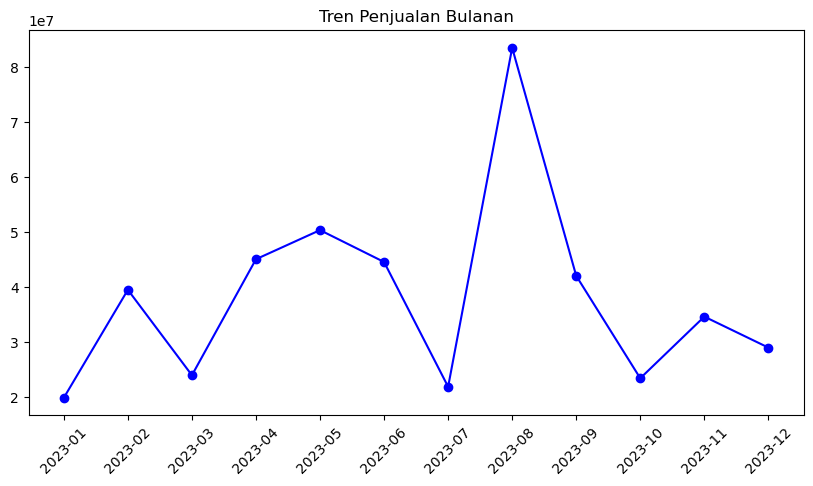

In [25]:
# 3. menentukan tren penjualan bulanan
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.savefig('Tren penjualan bulanan.png')
plt.show()

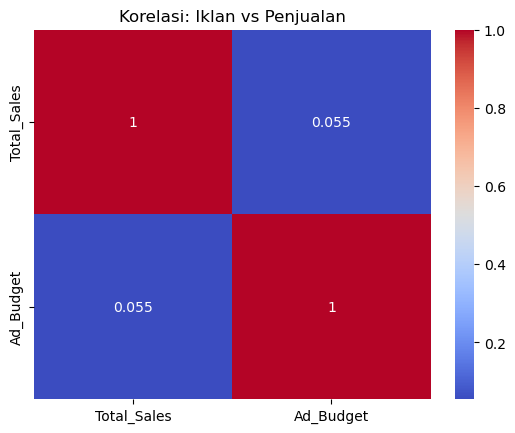

In [12]:
# pembuatan peta korelasi (heatmap) 

correlation = df[['Total_Sales', 'Ad_Budget']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi: Iklan vs Penjualan')
plt.show()

In [16]:
# Analisis RFM (Recency, Frequency, Monetary)

snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

# Hitung skor RFM
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days, # Recency
    'Order_ID': 'count',                                   # Frequency
    'Total_Sales': 'sum'                                   # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Memberikan skor 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

In [23]:
# regresi linear sederhana 

X = df[['Ad_Budget']]
y = df['Total_Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nKoefisien Iklan: {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test)}")


Koefisien Iklan: 0.18419827496237967
Akurasi Model (R2 Score): -0.1956467472142791


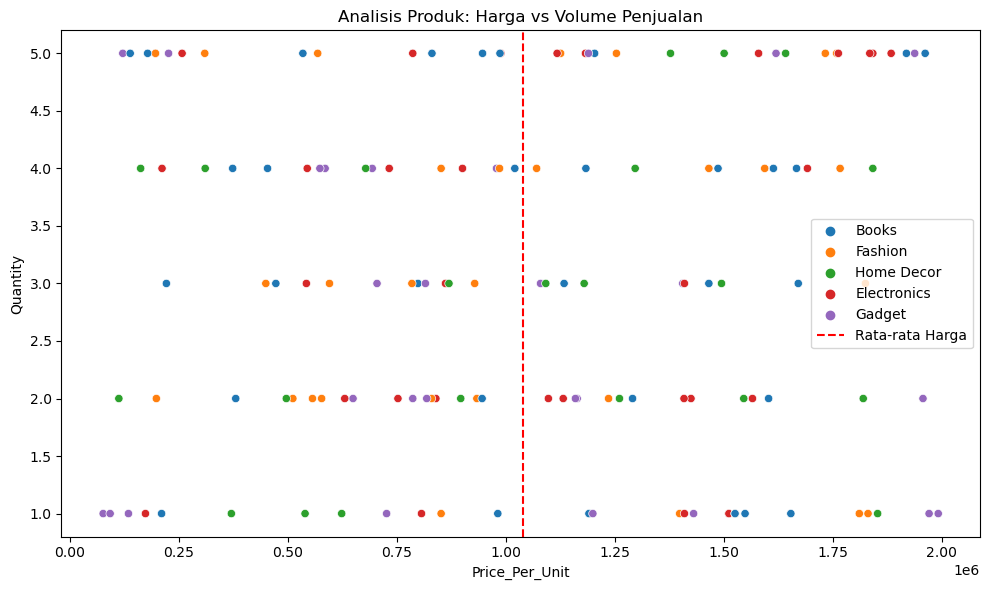

In [21]:
# produk underperformer (Scatter plot)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Price_Per_Unit', y='Quantity', hue='Product_Category')
plt.axvline(df['Price_Per_Unit'].mean(), color='red', linestyle='--', label='Rata-rata Harga')
plt.title('Analisis Produk: Harga vs Volume Penjualan')
plt.legend()
plt.tight_layout()
plt.savefig('underperformer.png')
plt.show()

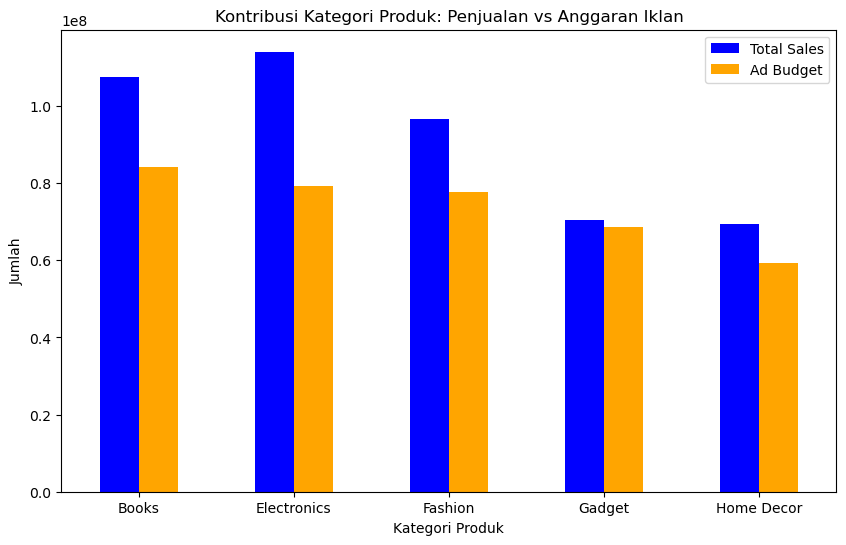

In [28]:
# kontribusi kategori: Total penjualan VS biaya iklan

kontribusi_kategori = df.groupby('Product_Category')[['Total_Sales', 'Ad_Budget']].sum()

kontribusi_kategori.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange'])


plt.title('Kontribusi Kategori Produk: Penjualan vs Anggaran Iklan')
plt.ylabel('Jumlah')
plt.xlabel('Kategori Produk')
plt.xticks(rotation=0)
plt.legend(['Total Sales', 'Ad Budget'])
plt.savefig('Kontribusi kategori: Tren penjualan vs iklan')
plt.show()

In [27]:
# UJI HIPOTESIS SEDERHANA (PENGARUH IKLAN TINGGI VS RENDAH)
median_ad = df['Ad_Budget'].median()

rata_penjualan_iklan_tinggi = df[df['Ad_Budget'] > median_ad]['Total_Sales'].mean()
rata_penjualan_iklan_rendah = df[df['Ad_Budget'] <= median_ad]['Total_Sales'].mean()

print("\n--- Hasil Uji Hipotesis Pengaruh Iklan ---")
print(f"Nilai Tengah (Median) Iklan: Rp {median_ad:,.2f}")
print(f"Rata-rata Penjualan (Iklan Tinggi) : Rp {rata_penjualan_iklan_tinggi:,.2f}")
print(f"Rata-rata Penjualan (Iklan Rendah) : Rp {rata_penjualan_iklan_rendah:,.2f}")

if rata_penjualan_iklan_tinggi > rata_penjualan_iklan_rendah:
    print("Kesimpulan: Ya, peningkatan Ad_Budget di atas median menghasilkan penjualan yang lebih tinggi!")
else:
    print("Kesimpulan: Tidak, iklan tinggi tidak menjamin penjualan lebih tinggi.")


--- Hasil Uji Hipotesis Pengaruh Iklan ---
Nilai Tengah (Median) Iklan: Rp 2,703,000.00
Rata-rata Penjualan (Iklan Tinggi) : Rp 3,114,126.76
Rata-rata Penjualan (Iklan Rendah) : Rp 3,291,305.56
Kesimpulan: Tidak, iklan tinggi tidak menjamin penjualan lebih tinggi.
